Original dataset size: (19577, 10)

Missing values:
Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64
Before cleaning: (19577, 10)
After cleaning: (19369, 10)

Yield stats after cleaning:
count    19369.000000
mean         4.093680
std         10.572811
min          0.003571
25%          0.600345
50%          1.025000
75%          2.319091
max         99.781875
Name: Yield, dtype: float64

Total Generated Features:
55

Selected Features:
['State' 'Crop' 'Season' 'log_area' 'log_production' 'State Season'
 'State log_area' 'State log_production' 'State log_rainfall'
 'State input_intensity' 'Crop Season' 'Crop log_production'
 'Crop log_rainfall' 'Season log_area' 'Season log_production'
 'Season log_rainfall' 'Season fertilizer_per_hectare'
 'year_from_start log_production' 'year_from_start log_rainfall'
 'log_area 

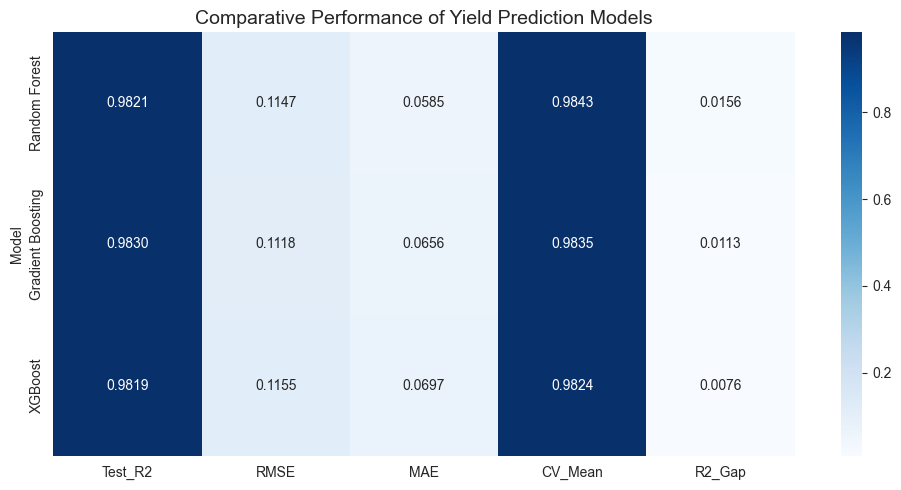


FINAL MODEL COMPARISON WITH OVERALL SCORE
               Model  Train_R2  Test_R2    RMSE     MAE     RAE   MAPE  \
0      Random Forest    0.9978   0.9821  0.1147  0.0585  0.0951   9.11   
1  Gradient Boosting    0.9943   0.9830  0.1118  0.0656  0.1067   9.79   
2            XGBoost    0.9895   0.9819  0.1155  0.0697  0.1135  11.41   

   R2_Gap  CV_Mean  CV_Std  Overall_Score  
0  0.0156   0.9843  0.0018       0.962270  
1  0.0113   0.9835  0.0019       0.962185  
2  0.0076   0.9824  0.0018       0.960725  

BEST MODEL SELECTION
Best Model : Random Forest
Overall Score : 0.9623


In [5]:
#yield model evaluation
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold
)

from sklearn.preprocessing import (
    LabelEncoder,
    PolynomialFeatures
)

from sklearn.feature_selection import SelectFromModel

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

import joblib


# -------------------------------
# Load Dataset
# -------------------------------

df = pd.read_csv("../data/clean_yield_data.csv")

print("Original dataset size:", df.shape)


# -------------------------------
# Data Cleaning
# -------------------------------

df = df.dropna()
df = df.drop_duplicates()

print("\nMissing values:")
print(df.isnull().sum())

print("Before cleaning:", df.shape)

df = df[df["Area"] > 0]
df = df[df["Production"] > 0]

# Yield validation
df = df[df["Yield"] <= 100]
df = df[df["Yield"] > 0]

print("After cleaning:", df.shape)


# ==================================================
# DATASET OVERVIEW
# ==================================================

print("\n" + "="*60)
print("DATASET OVERVIEW")
print("="*60)

print(f"Dataset Shape : {df.shape}")

print(f"Total Rows    : {df.shape[0]}")

print(f"Total Columns : {df.shape[1]}")


# ==================================================
# MISSING VALUES
# ==================================================

print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)

print(df.isnull().sum())

print(
    f"\nTotal Missing Values : "
    f"{df.isnull().sum().sum()}"
)


# ==================================================
# DUPLICATE VALUES
# ==================================================

print("\n" + "="*60)
print("DUPLICATE VALUES")
print("="*60)

duplicates = df.duplicated().sum()

print(
    f"Total Duplicate Rows : "
    f"{duplicates}"
)


# ==================================================
# DATA TYPES
# ==================================================

print("\n" + "="*60)
print("DATA TYPES")
print("="*60)

print(df.dtypes)


# ==================================================
# BASIC STATISTICS
# ==================================================

print("\n" + "="*60)
print("NUMERICAL SUMMARY")
print("="*60)

print(df.describe())


# ==================================================
# FINAL DATASET STATUS
# ==================================================

print("\n" + "="*60)
print("DATASET STATUS")
print("="*60)

if (
    df.isnull().sum().sum() == 0
    and duplicates == 0
):

    print(
        "✅ Dataset is clean and "
        "ready for model training."
    )

else:

    print(
        "⚠️ Dataset requires preprocessing."
    )

# print("\nYield stats after cleaning:")
# print(df["Yield"].describe())


# -------------------------------
# Log Transform Target
# -------------------------------

df["Yield"] = np.log1p(df["Yield"])

df["log_area"] = np.log1p(df["Area"])
df["log_production"] = np.log1p(df["Production"])


# -------------------------------
# Feature Engineering
# -------------------------------

df["fertilizer_per_hectare"] = (
    df["Fertilizer"] / df["Area"]
)

df["pesticide_per_hectare"] = (
    df["Pesticide"] / df["Area"]
)

df["input_intensity"] = (
    df["fertilizer_per_hectare"] +
    df["pesticide_per_hectare"]
)

df["log_rainfall"] = np.log1p(
    df["Annual_Rainfall"]
)

df["year_from_start"] = (
    df["Crop_Year"] -
    df["Crop_Year"].min()
)


# -------------------------------
# Encode Categorical Variables
# -------------------------------

le_state  = LabelEncoder()
le_crop   = LabelEncoder()
le_season = LabelEncoder()

df["Crop"] = (
    df["Crop"]
    .str.lower()
    .str.strip()
)

df["State"] = (
    df["State"]
    .str.lower()
    .str.strip()
)

df["Season"] = (
    df["Season"]
    .str.lower()
    .str.strip()
)

df["State"] = le_state.fit_transform(df["State"])

df["Crop"] = le_crop.fit_transform(df["Crop"])

df["Season"] = le_season.fit_transform(df["Season"])


# -------------------------------
# Base Features
# -------------------------------

features = [
    "State",
    "Crop",
    "Season",

    "year_from_start",
    

    "log_area",
    "log_production",
    

    "log_rainfall",

    "fertilizer_per_hectare",
    "pesticide_per_hectare",

    "input_intensity"
]

X = df[features]

y = df["Yield"]


# -------------------------------
# Automatic Feature Generation
# -------------------------------

poly = PolynomialFeatures(
    degree=2,
    interaction_only=True,
    include_bias=False
)

X_poly = poly.fit_transform(X)

generated_feature_names = (
    poly.get_feature_names_out(features)
)

print("\nTotal Generated Features:")
print(len(generated_feature_names))


# -------------------------------
# Automatic Feature Selection
# -------------------------------

selector_model = XGBRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

selector_model.fit(X_poly, y)

selector = SelectFromModel(
    selector_model,
    threshold="median",
    prefit=True
)

X_selected = selector.transform(X_poly)

selected_features = np.array(
    generated_feature_names
)[selector.get_support()]

print("\nSelected Features:")
print(selected_features)

# Final selected dataset
X = pd.DataFrame(
    X_selected,
    columns=selected_features
)




# -------------------------------
# Train Test Split
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"\nTraining samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")


# -------------------------------
# Multiple Model Comparison
# -------------------------------

models = {

    "Random Forest": RandomForestRegressor(

        n_estimators=300,

        max_depth=18,

        random_state=42,

        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(

        n_estimators=300,

        learning_rate=0.05,

        max_depth=6,

        random_state=42
    ),

    "XGBoost": XGBRegressor(

        n_estimators=900,

        learning_rate=0.025,

        max_depth=7,

        subsample=0.85,

        colsample_bytree=0.85,

        gamma=0.15,

        min_child_weight=4,

        reg_alpha=0.3,

        reg_lambda=1.2,

        random_state=42,

        n_jobs=-1
    )
}


# -------------------------------
# Result Storage
# -------------------------------

results = []

best_model = None

best_score = -999


# -------------------------------
# Train & Evaluate Models
# -------------------------------

for model_name, model in models.items():

    print(f"\n{'='*50}")

    print(f"Training {model_name}")

    print(f"{'='*50}")

    # ---------------------------
    # Training
    # ---------------------------

    model.fit(X_train, y_train)

    # ---------------------------
    # Predictions
    # ---------------------------

    train_preds = model.predict(X_train)

    test_preds = model.predict(X_test)

    # ---------------------------
    # Metrics
    # ---------------------------

    train_mae = mean_absolute_error(
        y_train,
        train_preds
    )

    test_mae = mean_absolute_error(
        y_test,
        test_preds
    )

    train_mse = mean_squared_error(
        y_train,
        train_preds
    )

    test_mse = mean_squared_error(
        y_test,
        test_preds
    )

    train_rmse = np.sqrt(train_mse)

    test_rmse = np.sqrt(test_mse)

    train_r2 = r2_score(
        y_train,
        train_preds
    )

    test_r2 = r2_score(
        y_test,
        test_preds
    )

    # ---------------------------
    # RAE
    # ---------------------------

    rae = (
        np.sum(np.abs(y_test - test_preds))
        /
        np.sum(
            np.abs(
                y_test - np.mean(y_test)
            )
        )
    )

    # ---------------------------
    # MAPE
    # ---------------------------

    mape = np.mean(
        np.abs(
            (y_test - test_preds)
            / y_test
        )
    ) * 100

    # ---------------------------
    # R2 Gap
    # ---------------------------

    r2_gap = train_r2 - test_r2

    # ---------------------------
    # Cross Validation
    # ---------------------------

    kf = KFold(

        n_splits=5,

        shuffle=True,

        random_state=42
    )

    cv_scores = cross_val_score(

        model,

        X,

        y,

        cv=kf,

        scoring="r2"
    )

    cv_mean = cv_scores.mean()

    cv_std = cv_scores.std()

    # ---------------------------
    # Print Results
    # ---------------------------

    print("\nModel Performance")

    print("-" * 40)

    print(f"Train R2 : {train_r2:.4f}")

    print(f"Test R2  : {test_r2:.4f}")

    print(f"RMSE     : {test_rmse:.4f}")

    print(f"MAE      : {test_mae:.4f}")

    print(f"RAE      : {rae:.4f}")

    print(f"MAPE     : {mape:.2f}%")

    print(f"R2 Gap   : {r2_gap:.4f}")

    print(f"CV Mean  : {cv_mean:.4f}")

    print(f"CV Std   : {cv_std:.4f}")

    # ---------------------------
    # Save Results
    # ---------------------------

    results.append({

        "Model": model_name,

        "Train_R2": round(train_r2, 4),

        "Test_R2": round(test_r2, 4),

        "RMSE": round(test_rmse, 4),

        "MAE": round(test_mae, 4),

        "RAE": round(rae, 4),

        "MAPE": round(mape, 2),

        "R2_Gap": round(r2_gap, 4),

        "CV_Mean": round(cv_mean, 4),

        "CV_Std": round(cv_std, 4)
    })

    # ---------------------------
    # Best Model Selection
    # ---------------------------

    if test_r2 > best_score:

        best_score = test_r2

        best_model = model


# -------------------------------
# Final Comparison Table
# -------------------------------

results_df = pd.DataFrame(results)

print(f"\n{'='*70}")

print("FINAL MODEL COMPARISON")

print(f"{'='*70}")

print(results_df)


# -------------------------------
# Best Model Result
# -------------------------------

# best_model_name = results_df.loc[
#     results_df["Test_R2"].idxmax(),
#     "Model"
# ]

# best_model_score = results_df["Test_R2"].max()

# print(f"\n{'='*70}")

# print("BEST MODEL SELECTION")

# print(f"{'='*70}")

# print(f"Best Model : {best_model_name}")

# print(f"Best Test R2 : {best_model_score:.4f}")


# -------------------------------
# Dataset Info
# -------------------------------

print(f"\n{'='*40}")

print("Dataset Info")

print(f"{'='*40}")

print(
    f"Total unique crops  : "
    f"{df['Crop'].nunique()}"
)

print(
    f"Total unique states : "
    f"{df['State'].nunique()}"
)


# ==================================================
# VISUALIZATION
# ==================================================

# ==================================================
# HEATMAP FOR RESEARCH PAPER
# ==================================================

plt.figure(figsize=(10, 5))

heatmap_data = results_df.set_index(
    "Model"
)[[
    "Test_R2",
    "RMSE",
    "MAE",
    "CV_Mean",
    "R2_Gap"
]]

sns.heatmap(

    heatmap_data,

    annot=True,

    cmap="Blues",

    fmt=".4f"
)

plt.title(
    "Comparative Performance of Yield Prediction Models",
    fontsize=14
)

plt.tight_layout()

plt.show()


# ==================================================
# OVERALL MODEL SCORING
# ==================================================

results_df["Overall_Score"] = (

    # Higher is better
    results_df["Test_R2"] * 0.35 +

    results_df["CV_Mean"] * 0.25 +

    # Lower is better
    (1 - results_df["RMSE"]) * 0.15 +

    (1 - results_df["MAE"]) * 0.15 +

    (1 - results_df["R2_Gap"]) * 0.10
)


# --------------------------------------------------
# Sort by Overall Score
# --------------------------------------------------

results_df = results_df.sort_values(

    by="Overall_Score",

    ascending=False
)


# --------------------------------------------------
# Print Updated Comparison
# --------------------------------------------------

print(f"\n{'='*70}")

print("FINAL MODEL COMPARISON WITH OVERALL SCORE")

print(f"{'='*70}")

print(results_df)


# --------------------------------------------------
# Best Model
# --------------------------------------------------

best_model_name = results_df.iloc[0]["Model"]

best_model_score = results_df.iloc[0]["Overall_Score"]


print(f"\n{'='*70}")

print("BEST MODEL SELECTION")

print(f"{'='*70}")

print(f"Best Model : {best_model_name}")

print(
    f"Overall Score : "
    f"{best_model_score:.4f}"
)


# -------------------------------
# Save Model & Objects
# -------------------------------

# print(f"\n{'='*40}")

# print("Saving Model & Encoders")

# print(f"{'='*40}")

# joblib.dump(
#     model,
#     "models/yield_model.pkl"
# )

# joblib.dump(
#     le_state,
#     "models/state_encoder.pkl"
# )

# joblib.dump(
#     le_crop,
#     "models/crop_encoder.pkl"
# )

# joblib.dump(
#     le_season,
#     "models/season_encoder.pkl"
# )

# joblib.dump(
#     poly,
#     "models/poly_transformer.pkl"
# )

# joblib.dump(
#     list(selected_features),
#     "models/yield_selected_features.pkl"
# )

# print("✅ Model saved → models/yield_model.pkl")

# print("🚀 All done! Model is ready.")



























Columns: Index(['STATE', 'SOIL_TYPE', 'N_SOIL', 'P_SOIL', 'K_SOIL', 'TEMPERATURE',
       'HUMIDITY', 'ph', 'RAINFALL', 'CROP_PRICE', 'CROP', 'Year', 'Month',
       'Supply Volume (tons)', 'Demand Volume (tons)'],
      dtype='object')
Original dataset shape: (26400, 15)

DATASET OVERVIEW
Dataset Shape : (26400, 15)
Total Rows    : 26400
Total Columns : 15

MISSING VALUES
STATE                   0
SOIL_TYPE               0
N_SOIL                  0
P_SOIL                  0
K_SOIL                  0
TEMPERATURE             0
HUMIDITY                0
ph                      0
RAINFALL                0
CROP_PRICE              0
CROP                    0
Year                    0
Month                   0
Supply Volume (tons)    0
Demand Volume (tons)    0
dtype: int64

Total Missing Values : 0

DUPLICATE VALUES
Total Duplicate Rows : 0

DATA TYPES
STATE                    object
SOIL_TYPE                object
N_SOIL                  float64
P_SOIL                  float64
K_SOIL      

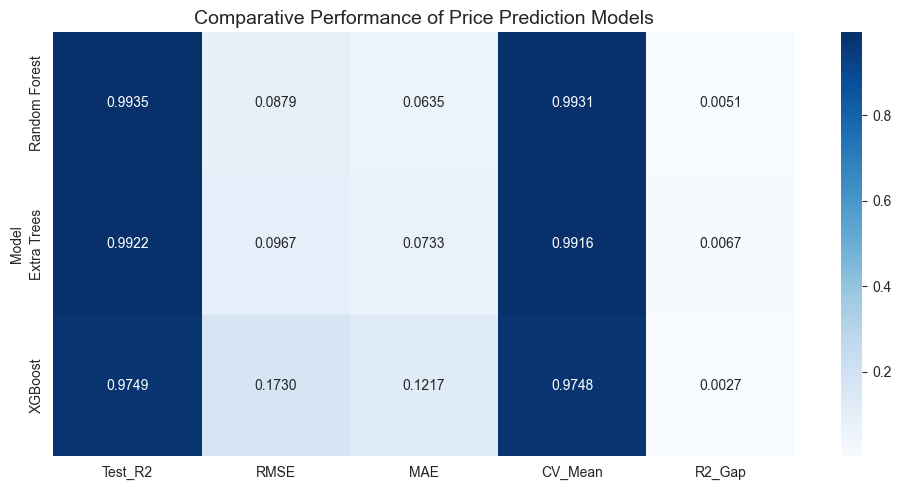


FINAL MODEL COMPARISON WITH OVERALL SCORE
           Model  Train_R2  Test_R2    RMSE     MAE     RAE  MAPE  R2_Gap  \
0  Random Forest    0.9986   0.9935  0.0879  0.0635  0.0819  0.92  0.0051   
1    Extra Trees    0.9989   0.9922  0.0967  0.0733  0.0946  1.07  0.0067   
2        XGBoost    0.9776   0.9749  0.1730  0.1217  0.1571  2.03  0.0027   

   CV_Mean  CV_Std  Overall_Score  
0   0.9931  0.0005        0.97278  
1   0.9916  0.0006        0.96900  
2   0.9748  0.0009        0.94044  

BEST MODEL SELECTION
Best Model : Random Forest
Overall Score : 0.9728


In [6]:
# price model evaluation


import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold
)

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor


# ------------------------------
# Load dataset
# ------------------------------

df = pd.read_csv("../data/crop_price_data_updated.csv")

print("Columns:", df.columns)
print("Original dataset shape:", df.shape)


# ------------------------------
# Data Cleaning
# ------------------------------

df = df.dropna()
df = df.drop_duplicates()



# ==================================================
# DATASET OVERVIEW
# ==================================================

print("\n" + "="*60)
print("DATASET OVERVIEW")
print("="*60)

print(f"Dataset Shape : {df.shape}")

print(f"Total Rows    : {df.shape[0]}")

print(f"Total Columns : {df.shape[1]}")


# ==================================================
# MISSING VALUES
# ==================================================

print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)

print(df.isnull().sum())

print(
    f"\nTotal Missing Values : "
    f"{df.isnull().sum().sum()}"
)


# ==================================================
# DUPLICATE VALUES
# ==================================================

print("\n" + "="*60)
print("DUPLICATE VALUES")
print("="*60)

duplicates = df.duplicated().sum()

print(
    f"Total Duplicate Rows : "
    f"{duplicates}"
)


# ==================================================
# DATA TYPES
# ==================================================

print("\n" + "="*60)
print("DATA TYPES")
print("="*60)

print(df.dtypes)


# ==================================================
# BASIC STATISTICS
# ==================================================

print("\n" + "="*60)
print("NUMERICAL SUMMARY")
print("="*60)

print(df.describe())


# ==================================================
# FINAL DATASET STATUS
# ==================================================

print("\n" + "="*60)
print("DATASET STATUS")
print("="*60)

if (
    df.isnull().sum().sum() == 0
    and duplicates == 0
):

    print(
        "✅ Dataset is clean and "
        "ready for model training."
    )

else:

    print(
        "⚠️ Dataset requires preprocessing."
    )


# ------------------------------
# Rename columns
# ------------------------------

df = df.rename(columns={
    "STATE": "State",
    "CROP": "Crop",
    "CROP_PRICE": "Price"
})

print("Dataset after cleaning:", df.shape)


# ------------------------------
# Convert numeric columns
# ------------------------------

num_cols = [
    "N_SOIL",
    "P_SOIL",
    "K_SOIL",
    "TEMPERATURE",
    "HUMIDITY",
    "ph",
    "RAINFALL",
    "Supply Volume (tons)",
    "Demand Volume (tons)",
    "Price"
]

for col in num_cols:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


df = df.dropna()


# ------------------------------
# Log Transform
# ------------------------------

# Target

df["Price"] = np.log1p(df["Price"])

# Features

df["RAINFALL"] = np.log1p(df["RAINFALL"])

df["TEMPERATURE"] = np.log1p(df["TEMPERATURE"])

df["HUMIDITY"] = np.log1p(df["HUMIDITY"])

df["Supply Volume (tons)"] = np.log1p(
    df["Supply Volume (tons)"]
)

df["Demand Volume (tons)"] = np.log1p(
    df["Demand Volume (tons)"]
)


# ------------------------------
# Encode categorical columns
# ------------------------------

le_state = LabelEncoder()
le_crop = LabelEncoder()
le_soil = LabelEncoder()


df["State"] = (
    df["State"]
    .astype(str)
    .str.lower()
    .str.strip()
)


df["Crop"] = (
    df["Crop"]
    .astype(str)
    .str.lower()
    .str.strip()
)


df["State"] = le_state.fit_transform(
    df["State"]
)


df["Crop"] = le_crop.fit_transform(
    df["Crop"]
)


df["SOIL_TYPE"] = le_soil.fit_transform(
    df["SOIL_TYPE"]
)


# ------------------------------
# Normalize soil values
# ------------------------------


df["N_SOIL"] = df["N_SOIL"] / 100

df["P_SOIL"] = df["P_SOIL"] / 100

df["K_SOIL"] = df["K_SOIL"] / 100


# ------------------------------
# Feature Engineering
# ------------------------------

# Soil fertility

df["NPK_SUM"] = (
    df["N_SOIL"] +
    df["P_SOIL"] +
    df["K_SOIL"]
)


# Temperature humidity interaction

df["TEMP_HUMIDITY"] = (
    df["TEMPERATURE"] *
    df["HUMIDITY"]
)


# Rain temperature interaction

df["RAIN_TEMP"] = (
    df["RAINFALL"] *
    df["TEMPERATURE"]
)


# Supply demand ratio

df["SUPPLY_DEMAND_RATIO"] = (
    df["Supply Volume (tons)"]
    /
    (
        df["Demand Volume (tons)"] + 1
    )
)


# Cyclical month encoding

df["Month_sin"] = np.sin(
    2 * np.pi * df["Month"] / 12
)


df["Month_cos"] = np.cos(
    2 * np.pi * df["Month"] / 12
)


# ------------------------------
# Feature Selection
# ------------------------------

features = [

    "Year",

    "Month_sin",

    "Month_cos",

    "State",

    "SOIL_TYPE",

    "Crop",

    "N_SOIL",

    "P_SOIL",

    "K_SOIL",

    "TEMPERATURE",

    "HUMIDITY",

    "ph",

    "RAINFALL",

    "Supply Volume (tons)",

    "Demand Volume (tons)",

    "SUPPLY_DEMAND_RATIO",

    "NPK_SUM",

    "TEMP_HUMIDITY",

    "RAIN_TEMP"
]


X = df[features]

y = df["Price"]


# ------------------------------
# Train Test Split
# ------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


print(f"\nTraining samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")


# ------------------------------
# Best models for this dataset
# ------------------------------

models = {

    "Random Forest": RandomForestRegressor(

        n_estimators=300,

        max_depth=18,

        random_state=42,

        n_jobs=-1
    ),


    "Extra Trees": ExtraTreesRegressor(

        n_estimators=300,

        max_depth=18,

        random_state=42,

        n_jobs=-1
    ),


    "XGBoost": XGBRegressor(

        n_estimators=500,

        learning_rate=0.03,

        max_depth=5,

        subsample=0.8,

        colsample_bytree=0.8,

        min_child_weight=5,

        gamma=0.3,

        reg_alpha=0.8,

        reg_lambda=2.0,

        random_state=42,

        n_jobs=-1
    )
}


# ------------------------------
# Store results
# ------------------------------

results = []


# ------------------------------
# Evaluate Models
# ------------------------------

for model_name, model in models.items():

    print(f"\n{'='*50}")

    print(f"Training {model_name}")

    print(f"{'='*50}")


    # --------------------------
    # Training
    # --------------------------

    model.fit(X_train, y_train)


    # --------------------------
    # Predictions
    # --------------------------

    train_pred = model.predict(X_train)

    test_pred = model.predict(X_test)


    # --------------------------
    # Metrics
    # --------------------------

    train_mae = mean_absolute_error(
        y_train,
        train_pred
    )

    test_mae = mean_absolute_error(
        y_test,
        test_pred
    )


    train_mse = mean_squared_error(
        y_train,
        train_pred
    )

    test_mse = mean_squared_error(
        y_test,
        test_pred
    )


    train_rmse = np.sqrt(train_mse)

    test_rmse = np.sqrt(test_mse)


    train_r2 = r2_score(
        y_train,
        train_pred
    )

    test_r2 = r2_score(
        y_test,
        test_pred
    )


    # --------------------------
    # RAE
    # --------------------------

    rae = (
        np.sum(np.abs(y_test - test_pred))
        /
        np.sum(
            np.abs(y_test - np.mean(y_test))
        )
    )


    # --------------------------
    # MAPE
    # --------------------------

    mape = np.mean(
        np.abs(
            (y_test - test_pred)
            / y_test
        )
    ) * 100


    # --------------------------
    # R2 Gap
    # --------------------------

    r2_gap = train_r2 - test_r2


    # --------------------------
    # Cross Validation
    # --------------------------

    kf = KFold(

        n_splits=5,

        shuffle=True,

        random_state=42
    )


    cv_scores = cross_val_score(

        model,

        X,

        y,

        cv=kf,

        scoring="r2"
    )


    cv_mean = cv_scores.mean()

    cv_std = cv_scores.std()


    # --------------------------
    # Print Results
    # --------------------------

    print("\nModel Performance")

    print("-" * 40)

    print(f"Train R2 : {train_r2:.4f}")

    print(f"Test R2  : {test_r2:.4f}")

    print(f"RMSE     : {test_rmse:.4f}")

    print(f"MAE      : {test_mae:.4f}")

    print(f"RAE      : {rae:.4f}")

    print(f"MAPE     : {mape:.2f}%")

    print(f"R2 Gap   : {r2_gap:.4f}")

    print(f"CV Mean  : {cv_mean:.4f}")

    print(f"CV Std   : {cv_std:.4f}")


    # --------------------------
    # Store Results
    # --------------------------

    results.append({

        "Model": model_name,

        "Train_R2": round(train_r2, 4),

        "Test_R2": round(test_r2, 4),

        "RMSE": round(test_rmse, 4),

        "MAE": round(test_mae, 4),

        "RAE": round(rae, 4),

        "MAPE": round(mape, 2),

        "R2_Gap": round(r2_gap, 4),

        "CV_Mean": round(cv_mean, 4),

        "CV_Std": round(cv_std, 4)
    })


# ------------------------------
# Final comparison table
# ------------------------------

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Test_R2",
    ascending=False
)


print(f"\n{'='*70}")

print("FINAL MODEL COMPARISON")

print(f"{'='*70}")

print(results_df)

# ==================================================
# VISUALIZATION
# ==================================================

# ==================================================
# HEATMAP FOR RESEARCH PAPER
# ==================================================

plt.figure(figsize=(10, 5))

heatmap_data = results_df.set_index(
    "Model"
)[[
    "Test_R2",
    "RMSE",
    "MAE",
    "CV_Mean",
    "R2_Gap"
]]

sns.heatmap(

    heatmap_data,

    annot=True,

    cmap="Blues",

    fmt=".4f"
)

plt.title(
    "Comparative Performance of Price Prediction Models",
    fontsize=14
)

plt.tight_layout()

plt.show()


# ==================================================
# OVERALL MODEL SCORING
# ==================================================

results_df["Overall_Score"] = (

    # Higher is better
    results_df["Test_R2"] * 0.35 +

    results_df["CV_Mean"] * 0.25 +

    # Lower is better
    (1 - results_df["RMSE"]) * 0.15 +

    (1 - results_df["MAE"]) * 0.15 +

    (1 - results_df["R2_Gap"]) * 0.10
)


# --------------------------------------------------
# Sort by Overall Score
# --------------------------------------------------

results_df = results_df.sort_values(

    by="Overall_Score",

    ascending=False
)


# --------------------------------------------------
# Print Updated Comparison
# --------------------------------------------------

print(f"\n{'='*70}")

print("FINAL MODEL COMPARISON WITH OVERALL SCORE")

print(f"{'='*70}")

print(results_df)


# --------------------------------------------------
# Best Model
# --------------------------------------------------

best_model_name = results_df.iloc[0]["Model"]

best_model_score = results_df.iloc[0]["Overall_Score"]


print(f"\n{'='*70}")

print("BEST MODEL SELECTION")

print(f"{'='*70}")

print(f"Best Model : {best_model_name}")

print(
    f"Overall Score : "
    f"{best_model_score:.4f}"
)








Original Shape: (8400, 8)
Original Crops: 28

Filtered Shape: (8400, 8)
Remaining Crops: 28

DATASET OVERVIEW
Dataset Shape : (8400, 8)
Total Rows    : 8400
Total Columns : 8

MISSING VALUES
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Total Missing Values : 0

DUPLICATE VALUES
Total Duplicate Rows : 0

Total Classes: 28
Features Used: 18

Train Shape: (6720, 18)
Test Shape : (1680, 18)

Training Random Forest

MODEL PERFORMANCE
----------------------------------------
Top-1 Accuracy : 0.9887
Top-3 Accuracy : 1.0000
Top-5 Accuracy : 1.0000
Precision      : 0.9888
Recall         : 0.9887
F1 Score       : 0.9887
CV Mean        : 0.9893
CV Std         : 0.0035

Training Extra Trees

MODEL PERFORMANCE
----------------------------------------
Top-1 Accuracy : 0.9881
Top-3 Accuracy : 1.0000
Top-5 Accuracy : 1.0000
Precision      : 0.9881
Recall         : 0.9881
F1 Score       : 0.9881
CV 

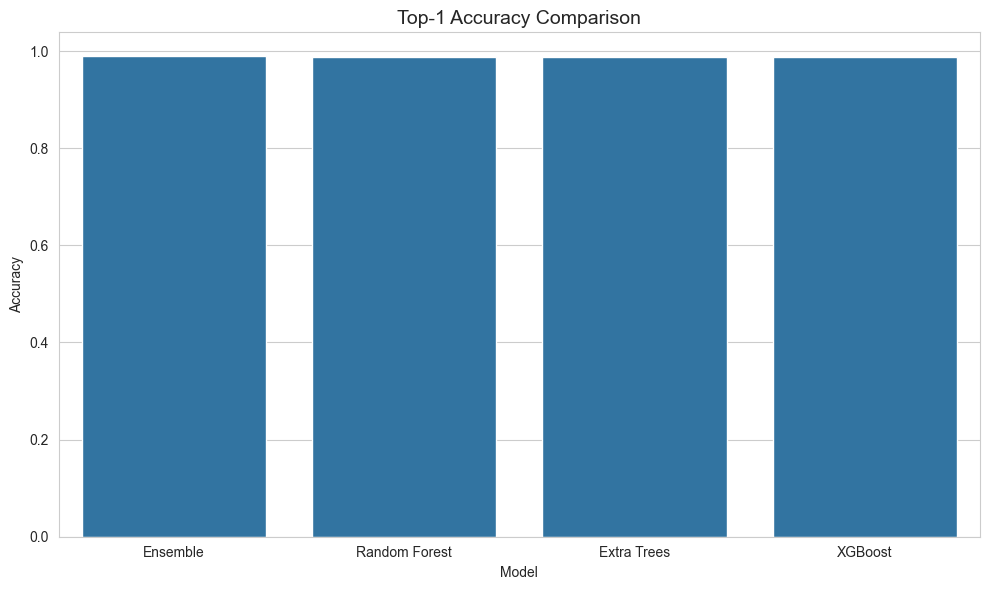

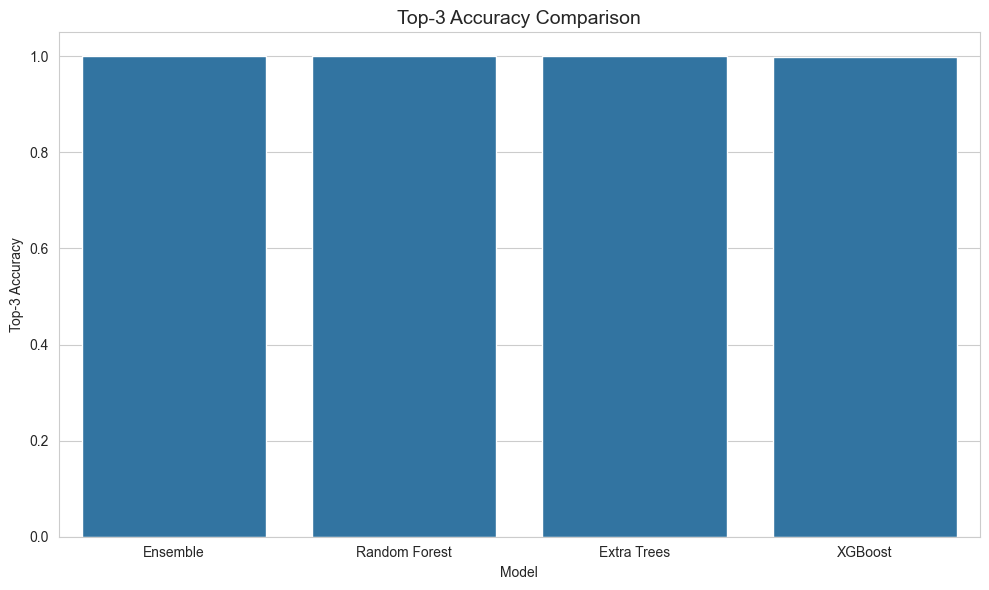

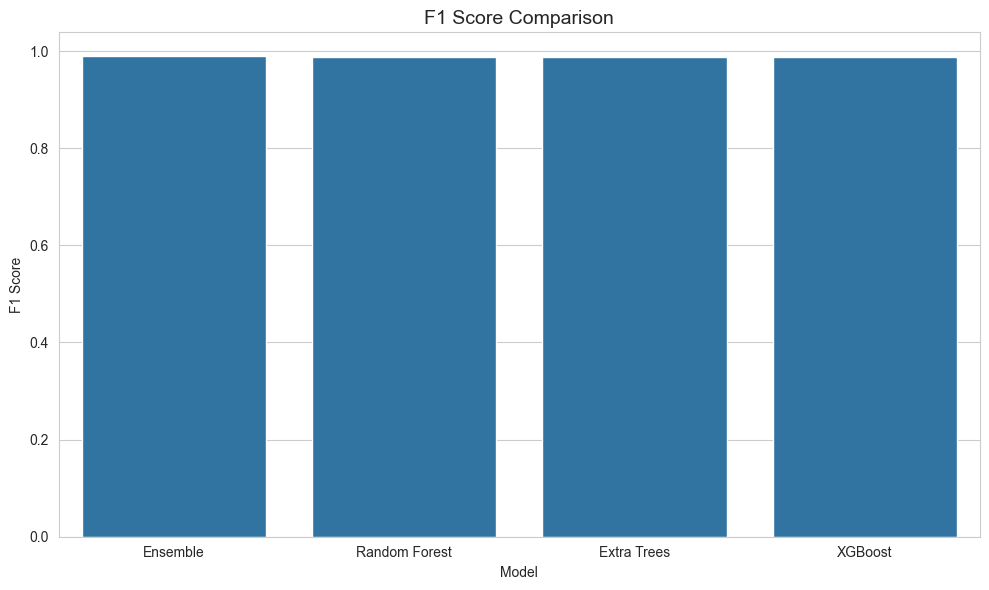

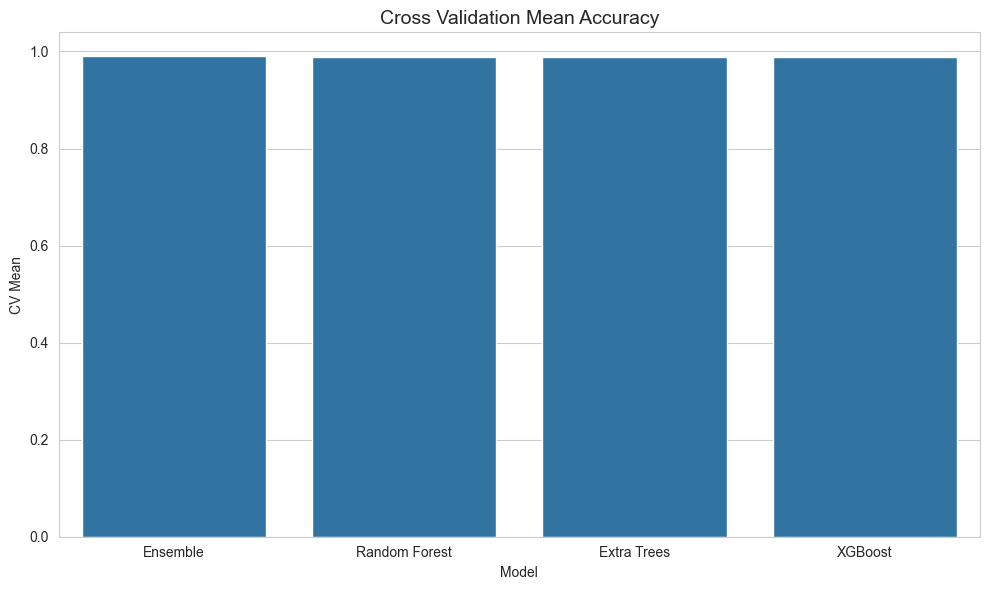

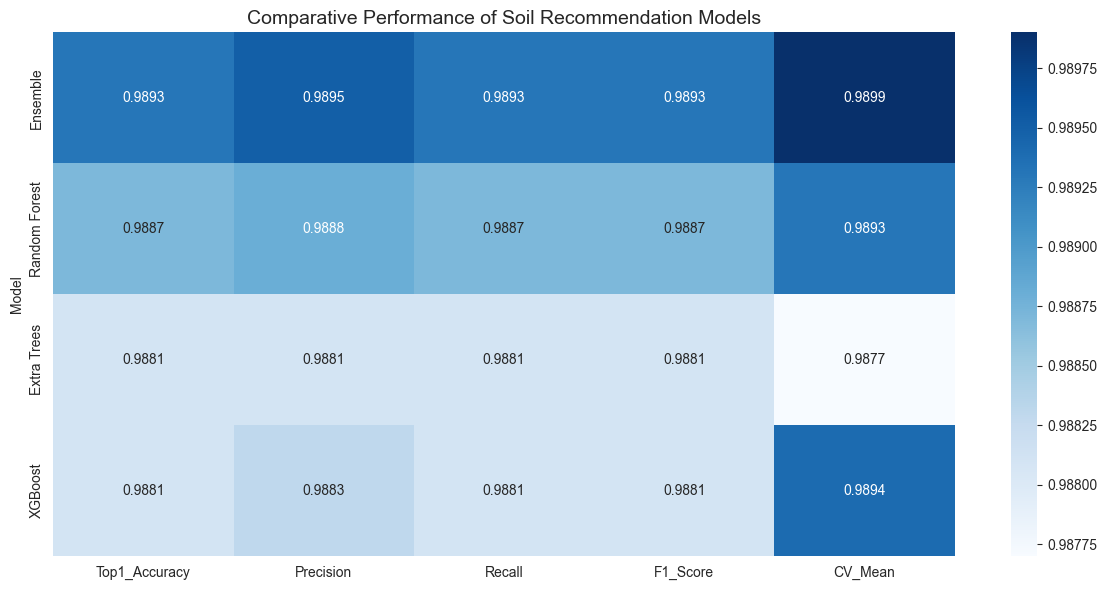


BEST MODEL SELECTION
Best Model : Ensemble
Best Top-3 Accuracy : 1.0000


In [8]:
#soil evaluation model
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    top_k_accuracy_score,
)

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    VotingClassifier,
)

from xgboost import XGBClassifier


# =====================================================
# CONFIG
# =====================================================

RANDOM_STATE = 42
TEST_SIZE = 0.20
MIN_SAMPLES = 50


# =====================================================
# LOAD DATASET
# =====================================================

df = pd.read_csv(
    "../data/soil_data_updated.csv"
)

print("Original Shape:", df.shape)
print("Original Crops:", df["label"].nunique())


# =====================================================
# BASIC CLEANING
# =====================================================

df["label"] = (
    df["label"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df = df.drop_duplicates().reset_index(drop=True)

df = df[
    (df["N"] >= 0)
    & (df["P"] >= 0)
    & (df["K"] >= 0)
    & (df["temperature"] > 0)
    & (df["humidity"] > 0)
    & (df["rainfall"] > 0)
]


# =====================================================
# REMOVE VERY SMALL CLASSES
# =====================================================

crop_counts = df["label"].value_counts()

valid_crops = crop_counts[
    crop_counts >= MIN_SAMPLES
].index

removed = (
    set(df["label"].unique())
    - set(valid_crops)
)

if removed:

    print(
        f"\nDropped Crops "
        f"(< {MIN_SAMPLES} samples):"
    )

    print(sorted(list(removed)))


df = df[
    df["label"].isin(valid_crops)
].reset_index(drop=True)

print("\nFiltered Shape:", df.shape)

print(
    "Remaining Crops:",
    df["label"].nunique()
)

# ==================================================
# DATASET OVERVIEW
# ==================================================

print("\n" + "="*60)
print("DATASET OVERVIEW")
print("="*60)

print(f"Dataset Shape : {df.shape}")

print(f"Total Rows    : {df.shape[0]}")

print(f"Total Columns : {df.shape[1]}")


# ==================================================
# MISSING VALUES
# ==================================================

print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)

print(df.isnull().sum())

print(
    f"\nTotal Missing Values : "
    f"{df.isnull().sum().sum()}"
)


# ==================================================
# DUPLICATE VALUES
# ==================================================

print("\n" + "="*60)
print("DUPLICATE VALUES")
print("="*60)

duplicates = df.duplicated().sum()

print(
    f"Total Duplicate Rows : "
    f"{duplicates}"
)


# =====================================================
# FEATURE ENGINEERING
# =====================================================

df["N_P_ratio"] = (
    df["N"] /
    (df["P"] + 1)
)

df["N_K_ratio"] = (
    
    df["N"] /
    (df["K"] + 1)
)

df["P_K_ratio"] = (
    df["P"] /
    (df["K"] + 1)
)

df["NPK_total"] = (
    df["N"] +
    df["P"] +
    df["K"]
)

df["temp_humidity"] = (
    df["temperature"] *
    df["humidity"] / 100
)

df["rain_humidity"] = (
    df["rainfall"] *
    df["humidity"] / 100
)

df["ph_N"] = (
    df["ph"] *
    df["N"]
)

df["ph_P"] = (
    df["ph"] *
    df["P"]
)

df["ph_K"] = (
    df["ph"] *
    df["K"]
)

df["temp_rain"] = (
    df["temperature"] *
    df["rainfall"] / 100
)

df["nutrient_balance"] = (

    abs(df["N"] - df["P"])

    + abs(df["P"] - df["K"])

    + abs(df["N"] - df["K"])
)


# =====================================================
# FEATURES
# =====================================================

FEATURES = [

    "N",
    "P",
    "K",

    "temperature",
    "humidity",
    "ph",
    "rainfall",

    "N_P_ratio",
    "N_K_ratio",
    "P_K_ratio",

    "NPK_total",

    "temp_humidity",
    "rain_humidity",

    "ph_N",
    "ph_P",
    "ph_K",

    "temp_rain",

    "nutrient_balance",
]

TARGET = "label"

X = df[FEATURES]

y = df[TARGET]


# =====================================================
# LABEL ENCODING
# =====================================================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print(
    f"\nTotal Classes: "
    f"{len(label_encoder.classes_)}"
)

print(
    f"Features Used: "
    f"{len(FEATURES)}"
)


# =====================================================
# TRAIN TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y_encoded,

    test_size=TEST_SIZE,

    stratify=y_encoded,

    random_state=RANDOM_STATE,
)

print(f"\nTrain Shape: {X_train.shape}")

print(f"Test Shape : {X_test.shape}")


# =====================================================
# SCALING
# =====================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

X_scaled = scaler.fit_transform(X)


# =====================================================
# MODELS
# =====================================================

rf_model = RandomForestClassifier(

    n_estimators=1200,

    max_depth=18,

    min_samples_split=4,

    min_samples_leaf=2,

    class_weight="balanced_subsample",

    random_state=RANDOM_STATE,

    n_jobs=-1,
)


et_model = ExtraTreesClassifier(

    n_estimators=1200,

    max_depth=18,

    min_samples_split=4,

    min_samples_leaf=2,

    class_weight="balanced_subsample",

    random_state=RANDOM_STATE,

    n_jobs=-1,
)


xgb_model = XGBClassifier(

    n_estimators=500,

    learning_rate=0.03,

    max_depth=8,

    subsample=0.85,

    colsample_bytree=0.85,

    objective="multi:softprob",

    eval_metric="mlogloss",

    reg_alpha=0.3,

    reg_lambda=1.5,

    gamma=0.1,

    min_child_weight=2,

    random_state=RANDOM_STATE,

    n_jobs=-1,
)


ensemble_model = VotingClassifier(

    estimators=[

        ("rf", rf_model),

        ("et", et_model),

        ("xgb", xgb_model),
    ],

    voting="soft",

    n_jobs=-1,
)


# =====================================================
# MODEL DICTIONARY
# =====================================================

models = {

    "Random Forest": rf_model,

    "Extra Trees": et_model,

    "XGBoost": xgb_model,

    "Ensemble": ensemble_model,
}


# =====================================================
# CROSS VALIDATION SETUP
# =====================================================

cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=RANDOM_STATE,
)


# =====================================================
# EVALUATION
# =====================================================

results = []


for model_name, model in models.items():

    print(f"\n{'='*60}")

    print(f"Training {model_name}")

    print(f"{'='*60}")


    # -----------------------------------------
    # Train
    # -----------------------------------------

    model.fit(
        X_train_scaled,
        y_train
    )


    # -----------------------------------------
    # Prediction
    # -----------------------------------------

    y_pred = model.predict(
        X_test_scaled
    )

    y_prob = model.predict_proba(
        X_test_scaled
    )


    # -----------------------------------------
    # Metrics
    # -----------------------------------------

    top1 = accuracy_score(
        y_test,
        y_pred
    )

    top3 = top_k_accuracy_score(
        y_test,
        y_prob,
        k=3
    )

    top5 = top_k_accuracy_score(
        y_test,
        y_prob,
        k=5
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )


    # -----------------------------------------
    # Cross Validation
    # -----------------------------------------

    cv_scores = cross_val_score(

        model,

        X_scaled,

        y_encoded,

        cv=cv,

        scoring="accuracy",

        n_jobs=-1,
    )

    cv_mean = cv_scores.mean()

    cv_std = cv_scores.std()


    # -----------------------------------------
    # Print Results
    # -----------------------------------------

    print("\nMODEL PERFORMANCE")

    print("-" * 40)

    print(f"Top-1 Accuracy : {top1:.4f}")

    print(f"Top-3 Accuracy : {top3:.4f}")

    print(f"Top-5 Accuracy : {top5:.4f}")

    print(f"Precision      : {precision:.4f}")

    print(f"Recall         : {recall:.4f}")

    print(f"F1 Score       : {f1:.4f}")

    print(f"CV Mean        : {cv_mean:.4f}")

    print(f"CV Std         : {cv_std:.4f}")


    # -----------------------------------------
    # Save Results
    # -----------------------------------------

    results.append({

        "Model": model_name,

        "Top1_Accuracy": round(top1, 4),

        "Top3_Accuracy": round(top3, 4),

        "Top5_Accuracy": round(top5, 4),

        "Precision": round(precision, 4),

        "Recall": round(recall, 4),

        "F1_Score": round(f1, 4),

        "CV_Mean": round(cv_mean, 4),

        "CV_Std": round(cv_std, 4),
    })


# =====================================================
# FINAL COMPARISON TABLE
# =====================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(

    by=[
        "Top3_Accuracy",
        "Top1_Accuracy",
        "F1_Score",
        "CV_Mean"
    ],

    ascending=False,
)

print(f"\n{'='*80}")

print("FINAL MODEL COMPARISON")

print(f"{'='*80}")

print(results_df)

# =====================================================
# VISUALIZATION
# =====================================================

sns.set_style("whitegrid")


# -----------------------------------------------------
# Top-1 Accuracy
# -----------------------------------------------------

plt.figure(figsize=(10, 6))

sns.barplot(

    x="Model",

    y="Top1_Accuracy",

    data=results_df
)

plt.title(
    "Top-1 Accuracy Comparison",
    fontsize=14
)

plt.ylabel("Accuracy")

plt.xlabel("Model")

plt.tight_layout()

plt.show()


# -----------------------------------------------------
# Top-3 Accuracy
# -----------------------------------------------------

plt.figure(figsize=(10, 6))

sns.barplot(

    x="Model",

    y="Top3_Accuracy",

    data=results_df
)

plt.title(
    "Top-3 Accuracy Comparison",
    fontsize=14
)

plt.ylabel("Top-3 Accuracy")

plt.xlabel("Model")

plt.tight_layout()

plt.show()


# -----------------------------------------------------
# F1 Score Comparison
# -----------------------------------------------------

plt.figure(figsize=(10, 6))

sns.barplot(

    x="Model",

    y="F1_Score",

    data=results_df
)

plt.title(
    "F1 Score Comparison",
    fontsize=14
)

plt.ylabel("F1 Score")

plt.xlabel("Model")

plt.tight_layout()

plt.show()


# -----------------------------------------------------
# Cross Validation Mean
# -----------------------------------------------------

plt.figure(figsize=(10, 6))

sns.barplot(

    x="Model",

    y="CV_Mean",

    data=results_df
)

plt.title(
    "Cross Validation Mean Accuracy",
    fontsize=14
)

plt.ylabel("CV Mean")

plt.xlabel("Model")

plt.tight_layout()

plt.show()


# -----------------------------------------------------
# Combined Heatmap
# -----------------------------------------------------

# =====================================================
# HEATMAP FOR SOIL MODEL COMPARISON
# =====================================================

import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(12, 6))

heatmap_data = results_df.set_index(
    "Model"
)[[
    "Top1_Accuracy",
    "Precision",
    "Recall",
    "F1_Score",
    "CV_Mean"
]]

sns.heatmap(

    heatmap_data,

    annot=True,

    cmap="Blues",

    fmt=".4f"
)

plt.title(
    "Comparative Performance of Soil Recommendation Models",
    fontsize=14
)

plt.tight_layout()

plt.show()


# =====================================================
# BEST MODEL
# =====================================================

best_model = results_df.iloc[0]["Model"]

best_score = results_df.iloc[0]["Top3_Accuracy"]

print(f"\n{'='*80}")

print("BEST MODEL SELECTION")

print(f"{'='*80}")

print(f"Best Model : {best_model}")

print(
    f"Best Top-3 Accuracy : "
    f"{best_score:.4f}"
)

Original dataset size: (19577, 10)

Missing values:
Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64
Before cleaning: (19577, 10)
After cleaning: (19369, 10)

Yield stats after cleaning:
count    19369.000000
mean         4.093680
std         10.572811
min          0.003571
25%          0.600345
50%          1.025000
75%          2.319091
max         99.781875
Name: Yield, dtype: float64

Total Generated Features:
55

Selected Features:
['State' 'Crop' 'Season' 'log_area' 'log_production' 'State Season'
 'State log_area' 'State log_production' 'State log_rainfall'
 'State input_intensity' 'Crop Season' 'Crop log_production'
 'Crop log_rainfall' 'Season log_area' 'Season log_production'
 'Season log_rainfall' 'Season fertilizer_per_hectare'
 'year_from_start log_production' 'year_from_start log_rainfall'
 'log_area 

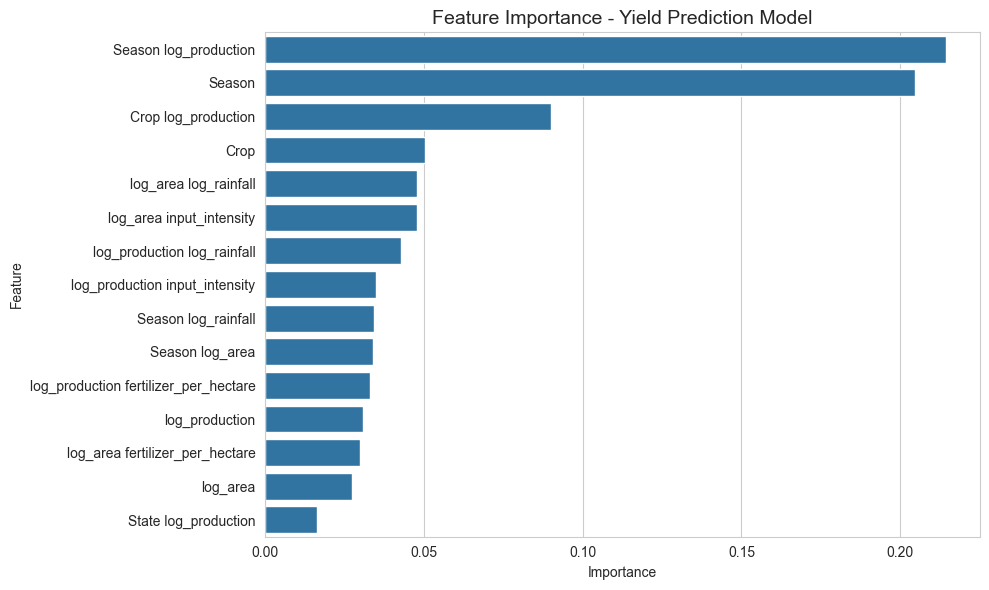


K-Fold Cross Validation (k=5)
CV R² Scores : [0.9817 0.9793 0.9829 0.9839 0.9844]
Mean CV R²   : 0.9824
Std CV R²    : 0.0018

Dataset Info
Total unique crops  : 55
Total unique states : 30


In [11]:
#train_yield_model.py

import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold
)

from sklearn.preprocessing import (
    LabelEncoder,
    PolynomialFeatures
)

from sklearn.feature_selection import SelectFromModel

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

import joblib


# -------------------------------
# Load Dataset
# -------------------------------

df = pd.read_csv("../data/clean_yield_data.csv")

print("Original dataset size:", df.shape)


# -------------------------------
# Data Cleaning
# -------------------------------

df = df.dropna()
df = df.drop_duplicates()

print("\nMissing values:")
print(df.isnull().sum())

print("Before cleaning:", df.shape)

df = df[df["Area"] > 0]
df = df[df["Production"] > 0]

# Yield validation
df = df[df["Yield"] <= 100]
df = df[df["Yield"] > 0]

print("After cleaning:", df.shape)

print("\nYield stats after cleaning:")
print(df["Yield"].describe())


# -------------------------------
# Log Transform Target
# -------------------------------

df["Yield"] = np.log1p(df["Yield"])

df["log_area"] = np.log1p(df["Area"])
df["log_production"] = np.log1p(df["Production"])


# -------------------------------
# Feature Engineering
# -------------------------------

df["fertilizer_per_hectare"] = (
    df["Fertilizer"] / df["Area"]
)

df["pesticide_per_hectare"] = (
    df["Pesticide"] / df["Area"]
)

df["input_intensity"] = (
    df["fertilizer_per_hectare"] +
    df["pesticide_per_hectare"]
)

df["log_rainfall"] = np.log1p(
    df["Annual_Rainfall"]
)

df["year_from_start"] = (
    df["Crop_Year"] -
    df["Crop_Year"].min()
)


# -------------------------------
# Encode Categorical Variables
# -------------------------------

le_state  = LabelEncoder()
le_crop   = LabelEncoder()
le_season = LabelEncoder()

df["Crop"] = (
    df["Crop"]
    .str.lower()
    .str.strip()
)

df["State"] = (
    df["State"]
    .str.lower()
    .str.strip()
)

df["Season"] = (
    df["Season"]
    .str.lower()
    .str.strip()
)

df["State"] = le_state.fit_transform(df["State"])

df["Crop"] = le_crop.fit_transform(df["Crop"])

df["Season"] = le_season.fit_transform(df["Season"])


# -------------------------------
# Base Features
# -------------------------------

features = [
    "State",
    "Crop",
    "Season",

    "year_from_start",
    

    "log_area",
    "log_production",
    

    "log_rainfall",

    "fertilizer_per_hectare",
    "pesticide_per_hectare",

    "input_intensity"
]

X = df[features]

y = df["Yield"]


# -------------------------------
# Automatic Feature Generation
# -------------------------------

poly = PolynomialFeatures(
    degree=2,
    interaction_only=True,
    include_bias=False
)

X_poly = poly.fit_transform(X)

generated_feature_names = (
    poly.get_feature_names_out(features)
)

print("\nTotal Generated Features:")
print(len(generated_feature_names))


# -------------------------------
# Automatic Feature Selection
# -------------------------------

selector_model = XGBRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

selector_model.fit(X_poly, y)

selector = SelectFromModel(
    selector_model,
    threshold="median",
    prefit=True
)

X_selected = selector.transform(X_poly)

selected_features = np.array(
    generated_feature_names
)[selector.get_support()]

print("\nSelected Features:")
print(selected_features)

# Final selected dataset
X = pd.DataFrame(
    X_selected,
    columns=selected_features
)




# -------------------------------
# Train Test Split
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"\nTraining samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")


# -------------------------------
# Model Definition
# -------------------------------

model = XGBRegressor(
    n_estimators=900,
    learning_rate=0.025,
    max_depth=7,
    subsample=0.85,
    colsample_bytree=0.85,
    gamma=0.15,
    min_child_weight=4,
    reg_alpha=0.3,
    reg_lambda=1.2,
    random_state=42,
    n_jobs=-1
)


# -------------------------------
# Model Training
# -------------------------------

print("\nTraining XGBoost...")

model.fit(X_train, y_train)

print("Training complete!")


# -------------------------------
# Evaluation — Train vs Test
# -------------------------------

train_preds = model.predict(X_train)

test_preds = model.predict(X_test)


# --------------------------------
# Train Metrics
# --------------------------------

train_mae = mean_absolute_error(
    y_train,
    train_preds
)

train_mse = mean_squared_error(
    y_train,
    train_preds
)

train_rmse = np.sqrt(train_mse)

train_r2 = r2_score(
    y_train,
    train_preds
)


# --------------------------------
# Test Metrics
# --------------------------------

test_mae = mean_absolute_error(
    y_test,
    test_preds
)

test_mse = mean_squared_error(
    y_test,
    test_preds
)

test_rmse = np.sqrt(test_mse)

test_r2 = r2_score(
    y_test,
    test_preds
)


# --------------------------------
# RAE (Relative Absolute Error)
# --------------------------------

rae = (
    np.sum(np.abs(y_test - test_preds))
    /
    np.sum(
        np.abs(y_test - np.mean(y_test))
    )
)


# --------------------------------
# MAPE
# --------------------------------

mape = np.mean(
    np.abs(
        (y_test - test_preds)
        / y_test
    )
) * 100


# --------------------------------
# R2 Gap
# --------------------------------

r2_gap = train_r2 - test_r2


# --------------------------------
# Print Metrics
# --------------------------------

print("\n========================================")
print("YIELD MODEL PERFORMANCE")
print("========================================")

print(
    f"{'Metric':<20}"
    f"{'Train':>12}"
    f"{'Test':>12}"
)

print("----------------------------------------")

print(
    f"{'MAE':<20}"
    f"{train_mae:>12.4f}"
    f"{test_mae:>12.4f}"
)

print(
    f"{'MSE':<20}"
    f"{train_mse:>12.4f}"
    f"{test_mse:>12.4f}"
)

print(
    f"{'RMSE':<20}"
    f"{train_rmse:>12.4f}"
    f"{test_rmse:>12.4f}"
)

print(
    f"{'R2 Score':<20}"
    f"{train_r2:>12.4f}"
    f"{test_r2:>12.4f}"
)

print("========================================")


# --------------------------------
# Additional Metrics
# --------------------------------

print("\nAdditional Metrics")
print("----------------------------------------")

print(f"RAE        : {rae:.4f}")

print(f"MAPE (%)   : {mape:.2f}")

print(f"R2 Gap     : {r2_gap:.4f}")


# --------------------------------
# Overfitting Check
# --------------------------------

print("\nOverfitting Analysis")
print("----------------------------------------")

if r2_gap < 0.05:
    print("✅ Excellent Generalization")

elif r2_gap < 0.10:
    print("✅ Good Generalization")

elif r2_gap < 0.15:
    print("⚠️ Moderate Overfitting")

else:
    print("❌ High Overfitting")


# ------------------------------
# Feature Importance
# ------------------------------

importance_df = pd.DataFrame({

    "Feature": X.columns,

    "Importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\n========================================")
print("TOP FEATURE IMPORTANCE")
print("========================================")

print(importance_df.head(10))


# ==================================================
# FEATURE IMPORTANCE
# ==================================================

feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=False
).head(15)


plt.figure(figsize=(10, 6))

sns.barplot(

    x="Importance",

    y="Feature",

    data=feature_importance
)

plt.title(
    "Feature Importance - Yield Prediction Model",
    fontsize=14
)

plt.tight_layout()

plt.show()

# -------------------------------
# Cross Validation
# -------------------------------

print(f"\n{'='*40}")

print("K-Fold Cross Validation (k=5)")

print(f"{'='*40}")

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=kf,
    scoring="r2"
)

print(f"CV R² Scores : {np.round(cv_scores, 4)}")

print(f"Mean CV R²   : {cv_scores.mean():.4f}")

print(f"Std CV R²    : {cv_scores.std():.4f}")


# -------------------------------
# Dataset Info
# -------------------------------

print(f"\n{'='*40}")

print("Dataset Info")

print(f"{'='*40}")

print(
    f"Total unique crops  : "
    f"{df['Crop'].nunique()}"
)

print(
    f"Total unique states : "
    f"{df['State'].nunique()}"
)


# -------------------------------
# Save Model & Objects
# -------------------------------

# print(f"\n{'='*40}")

# print("Saving Model & Encoders")

# print(f"{'='*40}")

# joblib.dump(
#     model,
#     "models/yield_model.pkl"
# )
# joblib.dump(
#     le_state,
#     "models/state_encoder.pkl"
# )
# joblib.dump(
#     le_crop,
#     "models/crop_encoder.pkl"
# )
# joblib.dump(
#     le_season,
#     "models/season_encoder.pkl"
# )
# joblib.dump(
#     poly,
#     "models/poly_transformer.pkl"
# )
# joblib.dump(
#     list(selected_features),
#     "models/yield_selected_features.pkl"
# )
# print("✅ Model saved → models/yield_model.pkl")

# print("🚀 All done! Model is ready.")



























Columns: Index(['STATE', 'SOIL_TYPE', 'N_SOIL', 'P_SOIL', 'K_SOIL', 'TEMPERATURE',
       'HUMIDITY', 'ph', 'RAINFALL', 'CROP_PRICE', 'CROP', 'Year', 'Month',
       'Supply Volume (tons)', 'Demand Volume (tons)'],
      dtype='object')
Original dataset shape: (26400, 15)
Dataset after cleaning: (26400, 15)

Training Price Model...

PRICE MODEL PERFORMANCE
Metric                     Train        Test
----------------------------------------
MAE                       0.0273      0.0635
MSE                       0.0015      0.0077
RMSE                      0.0392      0.0879
R2 Score                  0.9986      0.9935

Additional Metrics
----------------------------------------
RAE        : 0.0819
MAPE (%)   : 0.92
R2 Gap     : 0.0051

Overfitting Analysis
----------------------------------------
✅ Excellent Generalization

TOP FEATURE IMPORTANCE
                 Feature  Importance
13  Supply Volume (tons)    0.789813
4              SOIL_TYPE    0.091835
5                   Crop    0.0

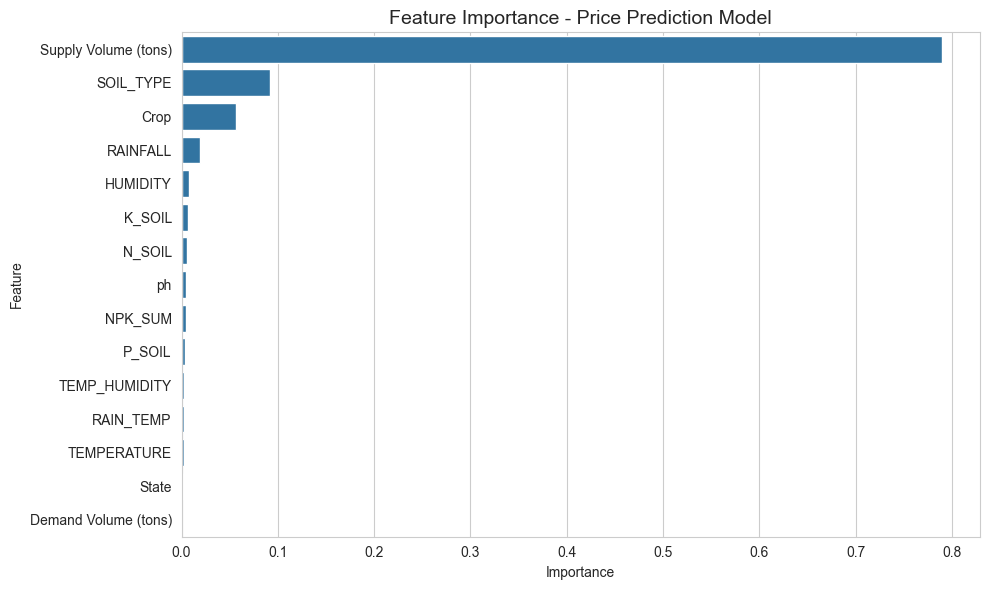


Cross Validation
CV R2 Scores : [0.9931 0.9934 0.9938 0.9919 0.9926]
Mean CV R2   : 0.9929
Std CV R2    : 0.0007


In [12]:
#train_price_model.py



import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
import joblib


# ------------------------------
# Load dataset
# ------------------------------

df = pd.read_csv("../data/crop_price_data_updated.csv")
df.columns = df.columns.str.strip()

print("Columns:", df.columns)
print("Original dataset shape:", df.shape)


# ------------------------------
# Data Cleaning
# ------------------------------

df = df.dropna()
df = df.drop_duplicates()




# Rename columns properly
df = df.rename(columns={
    "STATE": "State",
    "CROP": "Crop",
    "CROP_PRICE": "Price"
})
df["Crop"] = df["Crop"].str.lower().str.strip()
print("Dataset after cleaning:", df.shape)


# ------------------------------
# Convert numeric columns
# ------------------------------

num_cols = [
    "N_SOIL",
    "P_SOIL",
    "K_SOIL",
    "TEMPERATURE",
    "HUMIDITY",
    "ph",
    "RAINFALL",
    "Supply Volume (tons)",
    "Demand Volume (tons)",
    "Price"
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna()


# ------------------------------
# Log transform target
# ------------------------------

df["Price"] = np.log1p(df["Price"])
df["RAINFALL"] = np.log1p(df["RAINFALL"])
df["TEMPERATURE"] = np.log1p(df["TEMPERATURE"])
df["HUMIDITY"] = np.log1p(df["HUMIDITY"])
df["Supply Volume (tons)"] = np.log1p(
    df["Supply Volume (tons)"]
)

df["Demand Volume (tons)"] = np.log1p(
    df["Demand Volume (tons)"]
)


# ------------------------------
# Encode categorical variables
# ------------------------------
df["State"] = df["State"].str.lower().str.strip()
le_state = LabelEncoder()
le_crop = LabelEncoder()
le_soil = LabelEncoder()

df["State"] = le_state.fit_transform(df["State"])
df["Crop"] = le_crop.fit_transform(df["Crop"])
df["SOIL_TYPE"] = le_soil.fit_transform(df["SOIL_TYPE"])
df["N_SOIL"] = df["N_SOIL"] / 100
df["P_SOIL"] = df["P_SOIL"] / 100
df["K_SOIL"] = df["K_SOIL"] / 100

df["NPK_SUM"] = (
    df["N_SOIL"] +
    df["P_SOIL"] +
    df["K_SOIL"]
)

df["TEMP_HUMIDITY"] = (
    df["TEMPERATURE"] *
    df["HUMIDITY"]
)

df["RAIN_TEMP"] = (
    df["RAINFALL"] *
    df["TEMPERATURE"]
)
df["SUPPLY_DEMAND_RATIO"] = (
    df["Supply Volume (tons)"]
    /
    (
        df["Demand Volume (tons)"] + 1
    )
)
df["Month_sin"] = np.sin(
    2 * np.pi * df["Month"] / 12
)

df["Month_cos"] = np.cos(
    2 * np.pi * df["Month"] / 12
)



# ------------------------------
# Feature Selection
# ------------------------------

features = [
    "Year",
    "Month_sin",
    "Month_cos",
    "State",
    "SOIL_TYPE",
    "Crop",
    "N_SOIL",
    "P_SOIL",
    "K_SOIL",
    "TEMPERATURE",
    "HUMIDITY",
    "ph",
    "RAINFALL",

    "Supply Volume (tons)",
    "Demand Volume (tons)",
    "SUPPLY_DEMAND_RATIO",

    "NPK_SUM",
    "TEMP_HUMIDITY",
    "RAIN_TEMP"
]

X = df[features]
y = df["Price"]


# ------------------------------
# Train Test Split
# ------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


# ------------------------------
# Model Definition (balanced)
# ------------------------------

# model = XGBRegressor(
#     n_estimators=500,
#     learning_rate=0.03,
#     max_depth=5,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     min_child_weight=5,
#     gamma=0.3,
#     reg_alpha=0.8,
#     reg_lambda=2.0,
#     random_state=42,
#     n_jobs=-1
# )
model = RandomForestRegressor(

    n_estimators=300,

    max_depth=18,

    random_state=42,

    n_jobs=-1
)
# ------------------------------
# Training
# ------------------------------

print("\nTraining Price Model...")
model.fit(X_train, y_train)




# ------------------------------
# Evaluation
# ------------------------------

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Predictions
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)


# --------------------------------
# Train Metrics
# --------------------------------

train_mae = mean_absolute_error(
    y_train,
    train_pred
)

train_mse = mean_squared_error(
    y_train,
    train_pred
)

train_rmse = np.sqrt(train_mse)

train_r2 = r2_score(
    y_train,
    train_pred
)


# --------------------------------
# Test Metrics
# --------------------------------

test_mae = mean_absolute_error(
    y_test,
    test_pred
)

test_mse = mean_squared_error(
    y_test,
    test_pred
)

test_rmse = np.sqrt(test_mse)

test_r2 = r2_score(
    y_test,
    test_pred
)


# --------------------------------
# RAE (Relative Absolute Error)
# --------------------------------

rae = (
    np.sum(np.abs(y_test - test_pred))
    /
    np.sum(
        np.abs(y_test - np.mean(y_test))
    )
)


# --------------------------------
# MAPE
# --------------------------------

mape = np.mean(
    np.abs(
        (y_test - test_pred)
        / y_test
    )
) * 100


# --------------------------------
# R2 Gap
# --------------------------------

r2_gap = train_r2 - test_r2


# --------------------------------
# Print Metrics
# --------------------------------

print("\n========================================")
print("PRICE MODEL PERFORMANCE")
print("========================================")

print(
    f"{'Metric':<20}"
    f"{'Train':>12}"
    f"{'Test':>12}"
)

print("----------------------------------------")

print(
    f"{'MAE':<20}"
    f"{train_mae:>12.4f}"
    f"{test_mae:>12.4f}"
)

print(
    f"{'MSE':<20}"
    f"{train_mse:>12.4f}"
    f"{test_mse:>12.4f}"
)

print(
    f"{'RMSE':<20}"
    f"{train_rmse:>12.4f}"
    f"{test_rmse:>12.4f}"
)

print(
    f"{'R2 Score':<20}"
    f"{train_r2:>12.4f}"
    f"{test_r2:>12.4f}"
)

print("========================================")


# --------------------------------
# Additional Metrics
# --------------------------------

print("\nAdditional Metrics")
print("----------------------------------------")

print(f"RAE        : {rae:.4f}")

print(f"MAPE (%)   : {mape:.2f}")

print(f"R2 Gap     : {r2_gap:.4f}")


# --------------------------------
# Overfitting Check
# --------------------------------

print("\nOverfitting Analysis")
print("----------------------------------------")

if r2_gap < 0.05:
    print("✅ Excellent Generalization")

elif r2_gap < 0.10:
    print("✅ Good Generalization")

elif r2_gap < 0.15:
    print("⚠️ Moderate Overfitting")

else:
    print("❌ High Overfitting")


# ------------------------------
# Feature Importance
# ------------------------------

importance_df = pd.DataFrame({

    "Feature": features,

    "Importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\n========================================")
print("TOP FEATURE IMPORTANCE")
print("========================================")

print(importance_df.head(10))
# ==================================================
# FEATURE IMPORTANCE
# ==================================================

feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=False
).head(15)


plt.figure(figsize=(10, 6))

sns.barplot(

    x="Importance",

    y="Feature",

    data=feature_importance
)

plt.title(
    "Feature Importance - Price Prediction Model",
    fontsize=14
)

plt.tight_layout()

plt.show()


# ------------------------------
# Cross Validation
# ------------------------------

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("\n========================================")
print("Cross Validation")
print("========================================")

print(
    "CV R2 Scores :",
    np.round(scores, 4)
)

print(
    "Mean CV R2   :",
    round(scores.mean(), 4)
)

print(
    "Std CV R2    :",
    round(scores.std(), 4)
)





# ------------------------------
# Save Model + Encoders
# ------------------------------

# joblib.dump(model, "models/price_model.pkl")
# joblib.dump(le_state, "models/price_state_encoder.pkl")
# joblib.dump(le_crop, "models/price_crop_encoder.pkl")
# joblib.dump(le_soil, "models/price_soil_encoder.pkl")

# print("\n✅ Price model saved successfully!")





Original Shape: (8400, 8)
Original Crops: 28

Filtered Shape: (8400, 8)
Remaining Crops: 28
['arecanut', 'bajra', 'banana', 'barley', 'black pepper', 'castor seed', 'coconut', 'coriander', 'dry chillies', 'garlic', 'ginger', 'groundnut', 'jowar', 'jute', 'linseed', 'maize', 'niger seed', 'onion', 'potato', 'ragi', 'rice', 'sesamum', 'soyabean', 'sweet potato', 'tapioca', 'tobacco', 'turmeric', 'wheat']

Total Classes: 28
Features Used: 18
Train Shape: (6720, 18)
Test Shape : (1680, 18)

Running Cross Validation...
RandomForest    CV Accuracy: 0.9893 ± 0.0035
ExtraTrees      CV Accuracy: 0.9877 ± 0.0035
XGBoost         CV Accuracy: 0.9894 ± 0.0032
Ensemble        CV Accuracy: 0.9899 ± 0.0036

Training Final Ensemble...

MODEL EVALUATION
Top-1 Accuracy : 0.9893
Top-3 Accuracy : 1.0000
Top-5 Accuracy : 1.0000

Precision (Weighted): 0.9895
Recall (Weighted)   : 0.9893
F1 Score (Weighted) : 0.9893

Inference Time: 280.33 ms

Classification Report:

              precision    recall  f1-scor

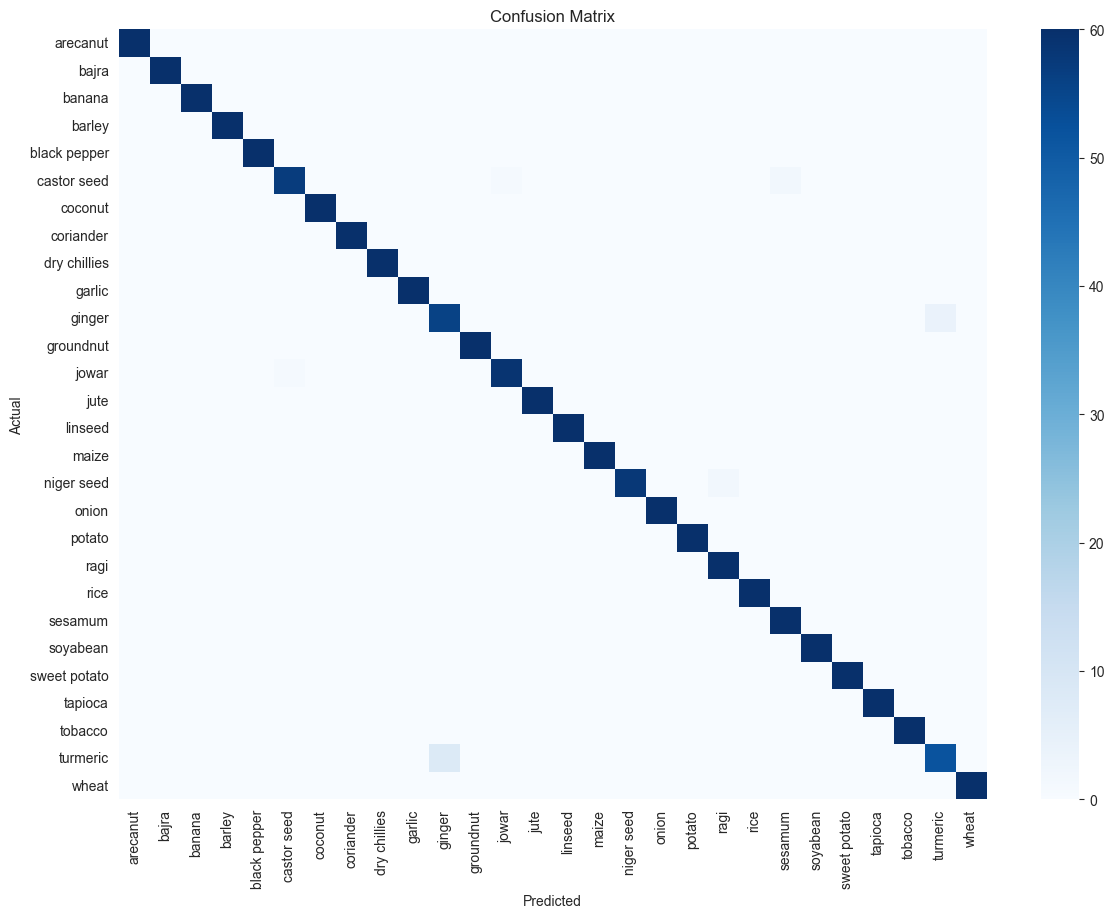

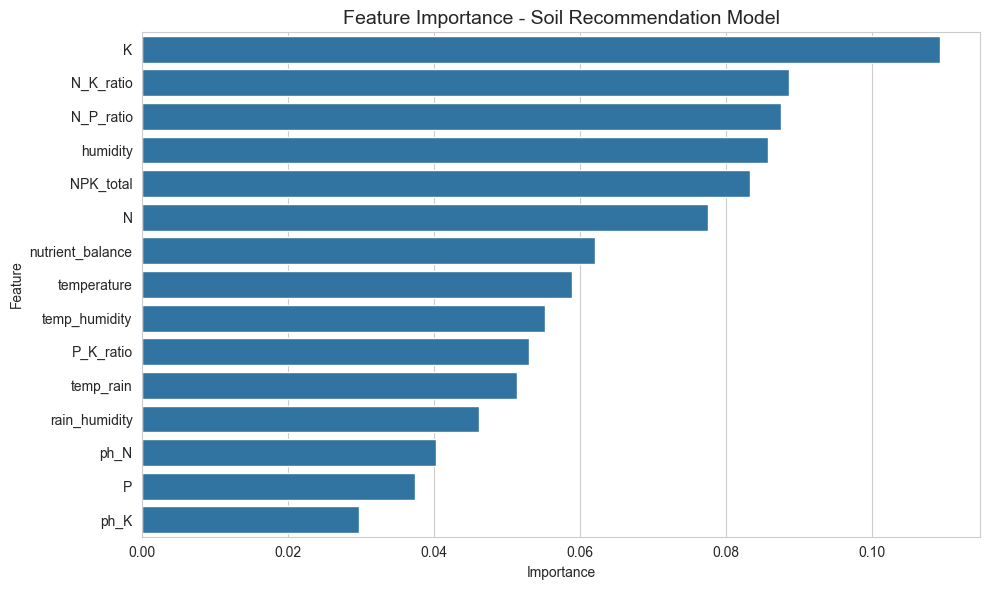

In [13]:
#train_soil_model.py
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import joblib
import time

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
)

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    top_k_accuracy_score,
)

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    VotingClassifier,
)

from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV

from xgboost import XGBClassifier


# =====================================================
# CONFIG
# =====================================================

RANDOM_STATE = 42
TEST_SIZE = 0.20
TOP_N = 5
MIN_SAMPLES = 50


# =====================================================
# LOAD DATASET
# =====================================================

# Dataset columns:
# N, P, K, temperature, humidity, ph, rainfall, label

df = pd.read_csv("../data/soil_data_updated.csv")

print("Original Shape:", df.shape)
print("Original Crops:", df["label"].nunique())


# =====================================================
# BASIC CLEANING
# =====================================================

# Lowercase crop names

df["label"] = (
    df["label"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Remove duplicates

df = df.drop_duplicates().reset_index(drop=True)

# Remove impossible values

df = df[
    (df["N"] >= 0)
    & (df["P"] >= 0)
    & (df["K"] >= 0)
    & (df["temperature"] > 0)
    & (df["humidity"] > 0)
    & (df["rainfall"] > 0)
]


# =====================================================
# REMOVE VERY SMALL CLASSES
# =====================================================

crop_counts = df["label"].value_counts()
valid_crops = crop_counts[crop_counts >= MIN_SAMPLES].index

removed = set(df["label"].unique()) - set(valid_crops)

if removed:
    print(f"\nDropped Crops (< {MIN_SAMPLES} samples):")
    print(sorted(list(removed)))


df = df[df["label"].isin(valid_crops)].reset_index(drop=True)

print("\nFiltered Shape:", df.shape)
print("Remaining Crops:", df["label"].nunique())
print(sorted(df["label"].unique()))


# =====================================================
# FEATURE ENGINEERING
# =====================================================

# Nutrient ratios

df["N_P_ratio"] = df["N"] / (df["P"] + 1)
df["N_K_ratio"] = df["N"] / (df["K"] + 1)
df["P_K_ratio"] = df["P"] / (df["K"] + 1)

# Total nutrients

df["NPK_total"] = df["N"] + df["P"] + df["K"]

# Climate interaction features

df["temp_humidity"] = (
    df["temperature"] * df["humidity"] / 100
)

df["rain_humidity"] = (
    df["rainfall"] * df["humidity"] / 100
)

# Soil chemistry interactions

df["ph_N"] = df["ph"] * df["N"]
df["ph_P"] = df["ph"] * df["P"]
df["ph_K"] = df["ph"] * df["K"]

# Moisture stress

df["temp_rain"] = (
    df["temperature"] * df["rainfall"] / 100
)

# Nutrient balance score

df["nutrient_balance"] = (
    abs(df["N"] - df["P"])
    + abs(df["P"] - df["K"])
    + abs(df["N"] - df["K"])
)


# =====================================================
# FEATURES
# =====================================================

FEATURES = [
    "N",
    "P",
    "K",
    "temperature",
    "humidity",
    "ph",
    "rainfall",
    "N_P_ratio",
    "N_K_ratio",
    "P_K_ratio",
    "NPK_total",
    "temp_humidity",
    "rain_humidity",
    "ph_N",
    "ph_P",
    "ph_K",
    "temp_rain",
    "nutrient_balance",
]

TARGET = "label"

X = df[FEATURES]
y = df[TARGET]


# =====================================================
# LABEL ENCODING
# =====================================================

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"\nTotal Classes: {len(label_encoder.classes_)}")
print(f"Features Used: {len(FEATURES)}")


# =====================================================
# TRAIN TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=TEST_SIZE,
    stratify=y_encoded,
    random_state=RANDOM_STATE,
)

print(f"Train Shape: {X_train.shape}")
print(f"Test Shape : {X_test.shape}")


# =====================================================
# SCALING
# =====================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# =====================================================
# MODELS
# =====================================================

rf_model = RandomForestClassifier(
    n_estimators=1200,
    max_depth=18,
    min_samples_split=4,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)


et_model = ExtraTreesClassifier(
    n_estimators=1200,
    max_depth=18,
    min_samples_split=4,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)


xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="multi:softprob",
    eval_metric="mlogloss",
    reg_alpha=0.3,
    reg_lambda=1.5,
    gamma=0.1,
    min_child_weight=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)


# =====================================================
# ENSEMBLE
# =====================================================

ensemble = VotingClassifier(
    estimators=[
        ("rf", rf_model),
        ("et", et_model),
        ("xgb", xgb_model),
    ],
    voting="soft",
    n_jobs=-1,
)


# =====================================================
# CROSS VALIDATION
# =====================================================

print("\nRunning Cross Validation...")

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

models = {
    "RandomForest": rf_model,
    "ExtraTrees": et_model,
    "XGBoost": xgb_model,
    "Ensemble": ensemble,
}

for name, model in models.items():
    scores = cross_val_score(
        model,
        scaler.fit_transform(X),
        y_encoded,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1,
    )

    print(
        f"{name:<15} "
        f"CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}"
    )


# =====================================================
# TRAIN FINAL MODEL
# =====================================================

print("\nTraining Final Ensemble...")

ensemble.fit(X_train_scaled, y_train)


# =====================================================
# PREDICTION
# =====================================================

y_pred = ensemble.predict(X_test_scaled)
y_prob = ensemble.predict_proba(X_test_scaled)


# =====================================================
# EVALUATION
# =====================================================

print("\nMODEL EVALUATION")
print("=" * 60)

# Top-K Accuracy

top1 = accuracy_score(y_test, y_pred)
top3 = top_k_accuracy_score(y_test, y_prob, k=3)
top5 = top_k_accuracy_score(y_test, y_prob, k=5)

print(f"Top-1 Accuracy : {top1:.4f}")
print(f"Top-3 Accuracy : {top3:.4f}")
print(f"Top-5 Accuracy : {top5:.4f}")

print()

print(
    f"Precision (Weighted): "
    f"{precision_score(y_test, y_pred, average='weighted'):.4f}"
)

print(
    f"Recall (Weighted)   : "
    f"{recall_score(y_test, y_pred, average='weighted'):.4f}"
)

print(
    f"F1 Score (Weighted) : "
    f"{f1_score(y_test, y_pred, average='weighted'):.4f}"
)

# =====================================================
# INFERENCE TIME
# =====================================================

start = time.time()

ensemble.predict(X_test_scaled[:1])

end = time.time()

print(
    f"\nInference Time: "
    f"{(end - start) * 1000:.2f} ms"
)


# =====================================================
# CLASSIFICATION REPORT
# =====================================================

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0,
    )
)


# =====================================================
# TOP-3 ACCURACY PER CROP
# =====================================================

# print("\nCrop-wise Top-3 Accuracy")
# print("=" * 60)

# for idx, crop in enumerate(label_encoder.classes_):

#     mask = (y_test == idx)

#     if mask.sum() == 0:
#         continue

#     crop_prob = y_prob[mask]
#     crop_true = y_test[mask]

#     crop_top3 = np.mean([
#         crop_true[i] in np.argsort(crop_prob[i])[-3:]
#         for i in range(len(crop_true))
#     ])

#     bar = "█" * int(crop_top3 * 20)

#     print(
#         f"{crop:<15} "
#         f"Top-3: {crop_top3:.2f} "
#         f"{bar} "
#         f"(n={mask.sum()})"
#     )


# =====================================================
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14, 10))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()



# =====================================================
# FEATURE IMPORTANCE
# =====================================================
# =====================================================
# FEATURE IMPORTANCE
# =====================================================

ensemble_model = joblib.load("../models/soil_model.pkl")

xgb_model = ensemble_model.named_estimators_["xgb"]

feature_importance = pd.DataFrame({

    "Feature": FEATURES,

    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=False
).head(15)

plt.figure(figsize=(10, 6))

sns.barplot(

    x="Importance",

    y="Feature",

    data=feature_importance
)

plt.title(
    "Feature Importance - Soil Recommendation Model",
    fontsize=14
)

plt.tight_layout()

plt.show()


# =====================================================
# SAVE ARTIFACTS
# =====================================================

# joblib.dump(ensemble, "models/soil_model.pkl")
# joblib.dump(scaler, "models/soil_scaler.pkl")
# joblib.dump(label_encoder, "models/soil_label_encoder.pkl")
# joblib.dump(FEATURES, "models/soil_features.pkl")

# print("\nAll model artifacts saved successfully.")


# =====================================================
# SMART PREDICTION FUNCTION
# =====================================================

CONFIDENCE_THRESHOLD = 0.45


def predict_crop(
    N,
    P,
    K,
    temperature,
    humidity,
    ph,
    rainfall,
    top_n=3,
):

    n_p_ratio = N / (P + 1)
    n_k_ratio = N / (K + 1)
    p_k_ratio = P / (K + 1)

    npk_total = N + P + K

    temp_humidity = temperature * humidity / 100
    rain_humidity = rainfall * humidity / 100

    ph_N = ph * N
    ph_P = ph * P
    ph_K = ph * K

    temp_rain = temperature * rainfall / 100

    nutrient_balance = (
        abs(N - P)
        + abs(P - K)
        + abs(N - K)
    )

    row = np.array([[
        N,
        P,
        K,
        temperature,
        humidity,
        ph,
        rainfall,
        n_p_ratio,
        n_k_ratio,
        p_k_ratio,
        npk_total,
        temp_humidity,
        rain_humidity,
        ph_N,
        ph_P,
        ph_K,
        temp_rain,
        nutrient_balance,
    ]])

    row_scaled = scaler.transform(row)

    probabilities = ensemble.predict_proba(row_scaled)[0]

    top_indices = np.argsort(probabilities)[::-1][:top_n]

    results = []

    for idx in top_indices:

        crop = label_encoder.classes_[idx]
        confidence = probabilities[idx]

        results.append({
            "crop": crop,
            "confidence": round(float(confidence), 4),
        })

    return results